In [1]:
import pandas as pd

In [2]:
import datetime
import matplotlib.pyplot as plt

In [3]:
objective = """Your objective is to explore the relationship between trader performance and market  
sentiment, uncover hidden patterns, and deliver insights that can drive smarter trading  
strategies."""

In [34]:
fear_db = pd.read_csv(fr"C:\Users\Noodl\Internship\Projects\PrimeTrade\DS\fear_greed_index.csv")
historical_db = pd.read_csv(fr"C:\Users\Noodl\Internship\Projects\PrimeTrade\DS\historical_data.csv")

In [5]:
fear_db

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [6]:
historical_db

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


## Your objective is to explore the relationship between trader performance and market   sentiment, uncover hidden patterns, and deliver insights that can drive smarter trading   strategies.

In [7]:
fear_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [8]:
historical_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [9]:
fear_db.describe().T

,count,mean,std,min,25%,50%,75%,max
timestamp,2644.0,1.631899e+09,6.597967e+07,1.517463e+09,1.574811e+09,1.631900e+09,1.688989e+09,1.746164e+09
value,2644.0,4.698109e+01,2.182768e+01,5.000000e+00,2.800000e+01,4.600000e+01,6.600000e+01,9.500000e+01


In [10]:
historical_db.describe().T

,count,mean,std,min,25%,50%,75%,max
Execution Price,211224.0,1.141472e+04,2.944765e+04,4.530000e-06,4.854700e+00,1.828000e+01,1.015800e+02,1.090040e+05
Size Tokens,211224.0,4.623365e+03,1.042729e+05,8.740000e-07,2.940000e+00,3.200000e+01,1.879025e+02,1.582244e+07
Size USD,211224.0,5.639451e+03,3.657514e+04,0.000000e+00,1.937900e+02,5.970450e+02,2.058960e+03,3.921431e+06
Start Position,211224.0,-2.994625e+04,6.738074e+05,-1.433463e+07,-3.762311e+02,8.472793e+01,9.337278e+03,3.050948e+07
Closed PnL,211224.0,4.874900e+01,9.191648e+02,-1.179901e+05,0.000000e+00,0.000000e+00,5.792797e+00,1.353291e+05
Order ID,211224.0,6.965388e+10,1.835753e+10,1.732711e+08,5.983853e+10,7.442939e+10,8.335543e+10,9.014923e+10
Fee,211224.0,1.163967e+00,6.758854e+00,-1.175712e+00,1.612094e-02,8.957750e-02,3.938110e-01,8.374716e+02
Trade ID,211224.0,5.628549e+14,3.257565e+14,0.000000e+00,2.810000e+14,5.620000e+14,8.460000e+14,1.130000e+15
Timestamp,211224.0,1.737744e+12,8.689920e+09,1.680000e+12,1.740000e+12,1.740000e+12,1.740000e+12,1.750000e+12


In [11]:
mapping = {
    0: "Fear",
    1: "Greed",
    2: "Extreme Fear",
    3: "Neutral",
    4: "Extreme Greed"
}

In [12]:
mappings = {
    "Fear":0,
    "Greed":1,
    "Extreme Fear":2,
    "Neutral":3,
    "Extreme Greed":4
}

In [13]:
values = fear_db['classification'].value_counts()

In [14]:
values.Fear

np.int64(781)

In [15]:
fear_db['mapped_class'] = fear_db['classification'].map(mappings)

In [16]:
fear_db

,timestamp,value,classification,date,mapped_class
0,1517463000,30,Fear,2018-02-01,0
1,1517549400,15,Extreme Fear,2018-02-02,2
2,1517635800,40,Fear,2018-02-03,0
3,1517722200,24,Extreme Fear,2018-02-04,2
4,1517808600,11,Extreme Fear,2018-02-05,2
...,...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28,3
2640,1745904600,60,Greed,2025-04-29,1
2641,1745991000,56,Greed,2025-04-30,1
2642,1746077400,53,Neutral,2025-05-01,3


In [17]:
temp_db = fear_db[['value','mapped_class']]

In [18]:
temp_db.corr()

,value,mapped_class
value,1.000000,0.406654
mapped_class,0.406654,1.000000


In [19]:
num = historical_db.select_dtypes(include="number")

In [20]:
num.corr()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
Execution Price,1.000000,-0.017185,0.189855,0.017241,-0.006505,0.125850,0.225265,0.001841,0.130714
Size Tokens,-0.017185,1.000000,0.013310,0.044660,0.005068,-0.043753,0.006710,-0.003848,-0.040949
Size USD,0.189855,0.013310,1.000000,0.007787,0.123589,0.045210,0.745939,0.000245,0.039755
Start Position,0.017241,0.044660,0.007787,1.000000,0.004066,-0.082799,0.010559,0.001165,-0.105487
Closed PnL,-0.006505,0.005068,0.123589,0.004066,1.000000,-0.007250,0.084020,0.003466,-0.009745
Order ID,0.125850,-0.043753,0.045210,-0.082799,-0.007250,1.000000,0.039303,0.003880,0.929166
Fee,0.225265,0.006710,0.745939,0.010559,0.084020,0.039303,1.000000,0.000940,0.036888
Trade ID,0.001841,-0.003848,0.000245,0.001165,0.003466,0.003880,0.000940,1.000000,0.002350
Timestamp,0.130714,-0.040949,0.039755,-0.105487,-0.009745,0.929166,0.036888,0.002350,1.000000


In [21]:
fear_db.head()

,timestamp,value,classification,date,mapped_class
0,1517463000,30,Fear,2018-02-01,0
1,1517549400,15,Extreme Fear,2018-02-02,2
2,1517635800,40,Fear,2018-02-03,0
3,1517722200,24,Extreme Fear,2018-02-04,2
4,1517808600,11,Extreme Fear,2018-02-05,2


In [22]:
historical_db.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [23]:
fear_db['timestamp_date'] = pd.to_datetime(fear_db['timestamp'], unit='s')

Text(0.5, 1.0, 'Time Series')

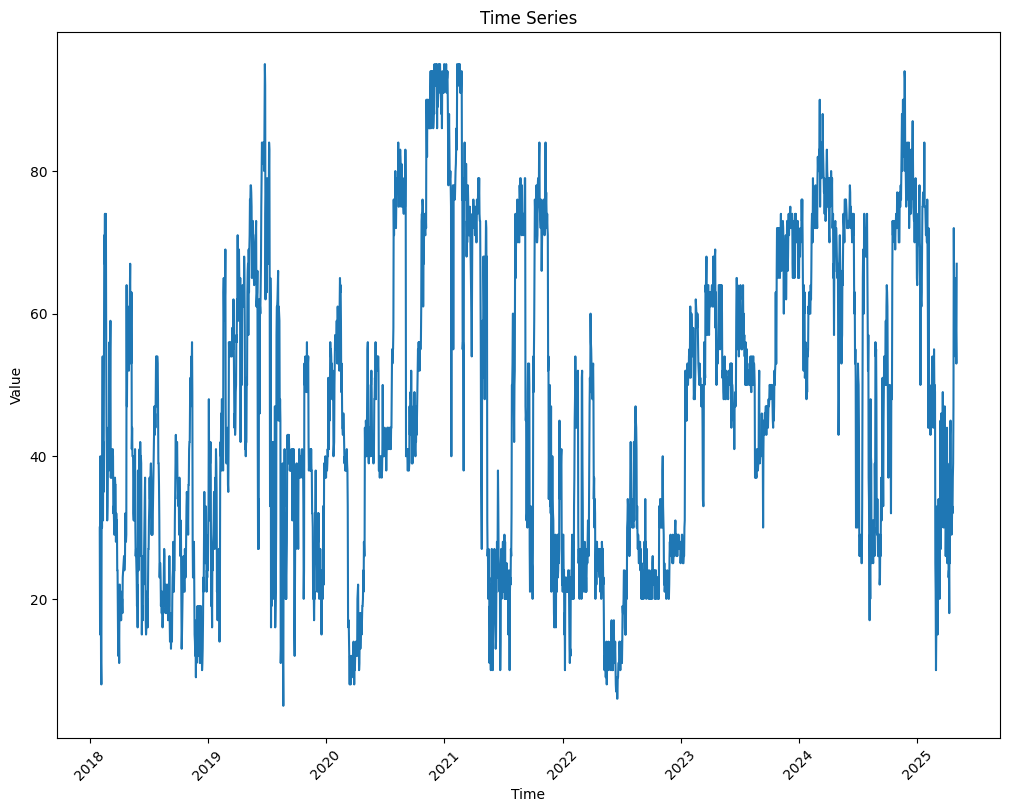

In [24]:
plt.figure(figsize=(10,8))
plt.plot(fear_db['timestamp_date'], fear_db['value'])
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylabel("Value")
plt.title("Time Series")


In [25]:
historical_db.head(1)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.0,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12


In [28]:
plt.figure(figsize=(10,8))
#plt.plot(historical_db['Timestamp'],historical_db['Start Position'])
#plt.plot(historical_db['Timestamp'],historical_db['Closed PnL'])
plt.plot((historical_db['Timestamp'],historical_db['Fee']))

 ...]

Error in callback <function flush_figures at 0x000001E7700697E0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

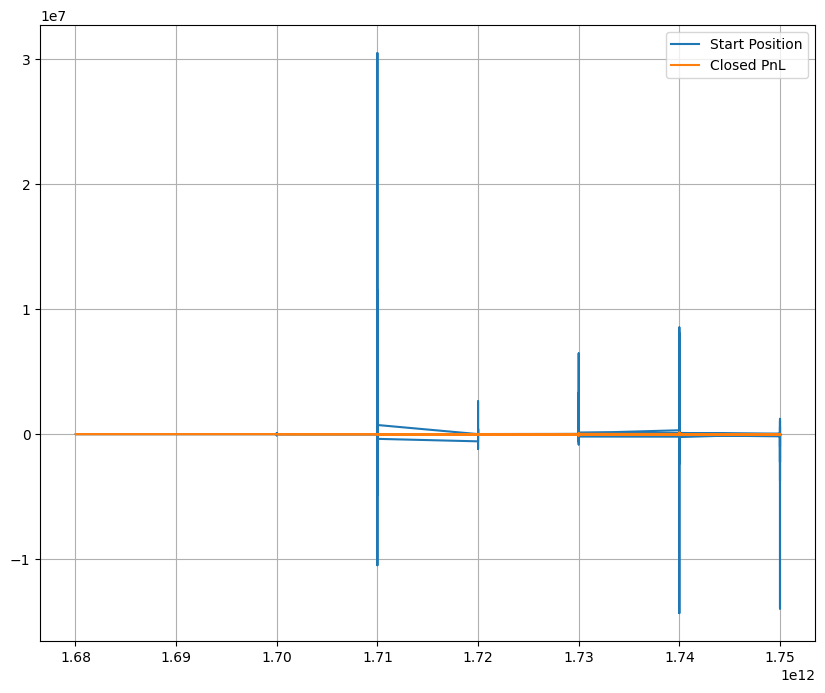

In [29]:
plt.figure(figsize=(10, 8))

plt.plot(historical_db["Timestamp"], historical_db["Start Position"], label="Start Position")
plt.plot(historical_db["Timestamp"], historical_db["Closed PnL"], label="Closed PnL")
#plt.plot(historical_db["Timestamp"], historical_db["Fee"], label="Fee")

plt.legend()
plt.grid(True)
plt.show()

In [30]:
historical_db.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [31]:
historical_db[["Start Position", "Closed PnL", "Fee"]].describe()

,Start Position,Closed PnL,Fee
count,2.112240e+05,211224.000000,211224.000000
mean,-2.994625e+04,48.749001,1.163967
std,6.738074e+05,919.164828,6.758854
min,-1.433463e+07,-117990.104100,-1.175712
25%,-3.762311e+02,0.000000,0.016121
50%,8.472793e+01,0.000000,0.089578
75%,9.337278e+03,5.792797,0.393811
max,3.050948e+07,135329.090100,837.471593


In [35]:
fear_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [36]:
historical_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [49]:
historical_db["Timestamp"].head()

0   2024-10-27 03:33:20
1   2024-10-27 03:33:20
2   2024-10-27 03:33:20
3   2024-10-27 03:33:20
4   2024-10-27 03:33:20
Name: Timestamp, dtype: datetime64[ns]

In [50]:
historical_db["Timestamp"] = pd.to_datetime(
    historical_db["Timestamp"],
    unit="ms"      # use "s" if they're in seconds
)

In [51]:
historical_db["Timestamp"].head()


0   2024-10-27 03:33:20
1   2024-10-27 03:33:20
2   2024-10-27 03:33:20
3   2024-10-27 03:33:20
4   2024-10-27 03:33:20
Name: Timestamp, dtype: datetime64[ns]

In [52]:
historical_db["Date"] = historical_db["Timestamp"].dt.date
fear_db["Date"] = pd.to_datetime(fear_db["date"]).dt.date

merged = historical_db.merge(
    fear_db[["Date", "value", "classification"]],
    on="Date",
    how="left"
)

In [53]:
merged

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,74.0,Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,2025-06-15 15:06:40,2025-06-15,NaN,NaN
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,2025-06-15 15:06:40,2025-06-15,NaN,NaN
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,2025-06-15 15:06:40,2025-06-15,NaN,NaN
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,2025-06-15 15:06:40,2025-06-15,NaN,NaN


In [59]:
merged.duplicated().sum()

np.int64(0)

In [60]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,74.0,Greed


In [63]:
important = merged.drop(columns=[
    "Account",
    "Transaction Hash",
    "Order ID"
])

In [64]:
important = merged[[
    "Timestamp",
    "Coin",
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Side",
    "Start Position",
    "Direction",
    "Closed PnL",
    "Fee",
    "value",
    "classification"
]]

In [70]:
important

,Timestamp,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Fee,value,classification
0,2024-10-27 03:33:20,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0000,0.345404,74.0,Greed
1,2024-10-27 03:33:20,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0000,0.005600,74.0,Greed
2,2024-10-27 03:33:20,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0000,0.050431,74.0,Greed
3,2024-10-27 03:33:20,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0000,0.050043,74.0,Greed
4,2024-10-27 03:33:20,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0000,0.003055,74.0,Greed
...,...,...,...,...,...,...,...,...,...,...,...,...
211219,2025-06-15 15:06:40,FARTCOIN,1.1010,382.20,420.80,SELL,7546.600000,Close Long,-20.2566,0.042080,NaN,NaN
211220,2025-06-15 15:06:40,FARTCOIN,1.1010,2124.10,2338.63,SELL,7164.400000,Close Long,-112.5773,0.233863,NaN,NaN
211221,2025-06-15 15:06:40,FARTCOIN,1.1010,423.40,466.16,SELL,5040.300000,Close Long,-22.4402,0.046616,NaN,NaN
211222,2025-06-15 15:06:40,FARTCOIN,1.1010,3599.80,3963.38,SELL,4616.900000,Close Long,-190.7894,0.396337,NaN,NaN


In [75]:
important = merged[[
    "Timestamp",
    "Coin",
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Side",
    "Direction",
    "Closed PnL",
    "Fee",
    "Start Position",
    "value",
    "classification"
]]

In [76]:
important.info()
important.describe()
important.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Timestamp        211224 non-null  datetime64[ns]
 1   Coin             211224 non-null  object        
 2   Execution Price  211224 non-null  float64       
 3   Size Tokens      211224 non-null  float64       
 4   Size USD         211224 non-null  float64       
 5   Side             211224 non-null  object        
 6   Direction        211224 non-null  object        
 7   Closed PnL       211224 non-null  float64       
 8   Fee              211224 non-null  float64       
 9   Start Position   211224 non-null  float64       
 10  value            184263 non-null  float64       
 11  classification   184263 non-null  object        
dtypes: datetime64[ns](1), float64(7), object(4)
memory usage: 19.3+ MB


,Timestamp,Coin,Execution Price,Size Tokens,Size USD,Side,Direction,Closed PnL,Fee,Start Position,value,classification
0,2024-10-27 03:33:20,@107,7.9769,986.87,7872.16,BUY,Buy,0.0,0.345404,0.000000,74.0,Greed
1,2024-10-27 03:33:20,@107,7.9800,16.00,127.68,BUY,Buy,0.0,0.005600,986.524596,74.0,Greed
2,2024-10-27 03:33:20,@107,7.9855,144.09,1150.63,BUY,Buy,0.0,0.050431,1002.518996,74.0,Greed
3,2024-10-27 03:33:20,@107,7.9874,142.98,1142.04,BUY,Buy,0.0,0.050043,1146.558564,74.0,Greed
4,2024-10-27 03:33:20,@107,7.9894,8.73,69.75,BUY,Buy,0.0,0.003055,1289.488521,74.0,Greed


array([[<Axes: title={'center': 'Timestamp'}>,
        <Axes: title={'center': 'Execution Price'}>,
        <Axes: title={'center': 'Size Tokens'}>],
       [<Axes: title={'center': 'Size USD'}>,
        <Axes: title={'center': 'Closed PnL'}>,
        <Axes: title={'center': 'Fee'}>],
       [<Axes: title={'center': 'Start Position'}>,
        <Axes: title={'center': 'value'}>, <Axes: >]], dtype=object)

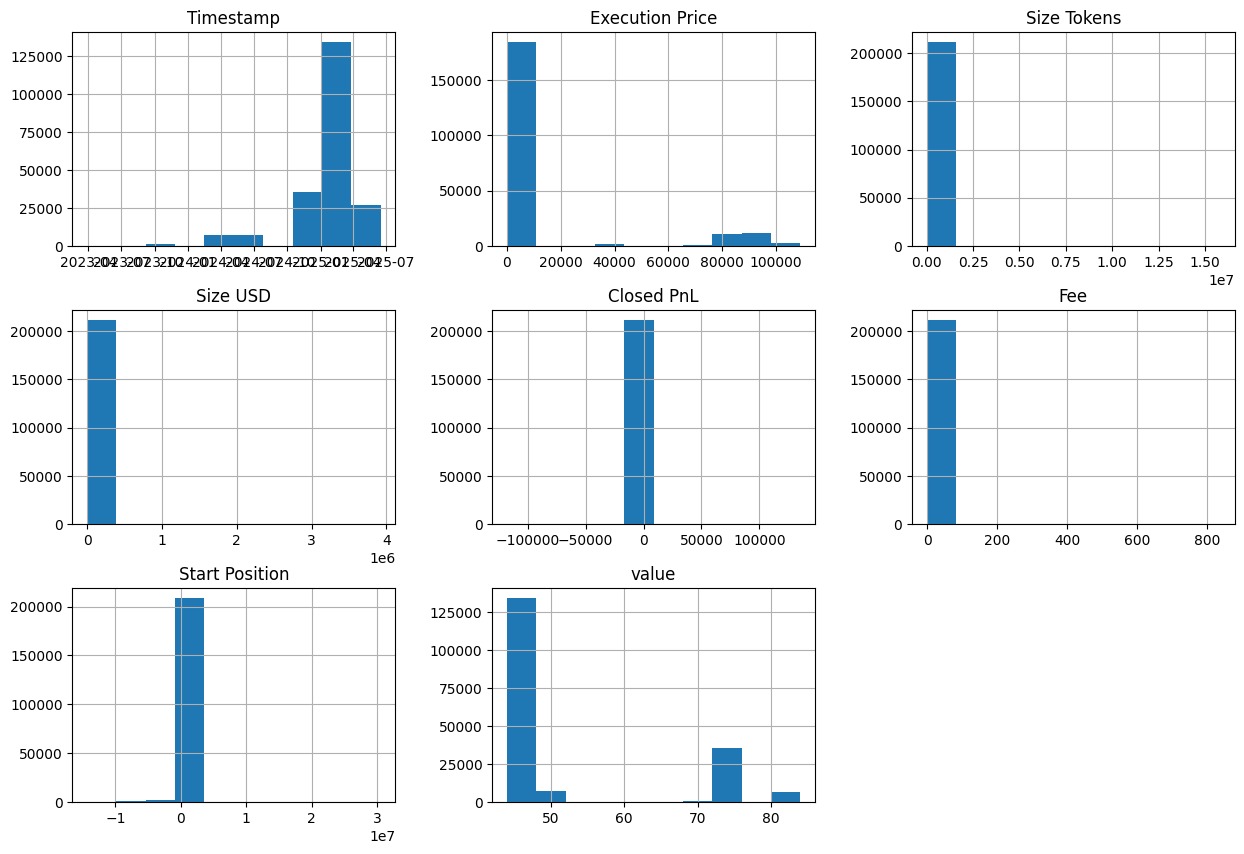

In [77]:
important.hist(figsize=(15,10))

(array([1.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 5.00000e+00, 1.70000e+01, 9.20000e+01, 2.10944e+05,
        1.07000e+02, 4.30000e+01, 4.00000e+00, 3.00000e+00, 2.00000e+00,
        3.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00, 1.00000e+00]),
 array([-117990.1041 , -105324.14439,  -92658.18468,  -79992.22497,
         -67326.26526,  -54660.30555,  -41994.34584,  -29328.38613,
         -16662.42642,   -3996.46671,    8669.493  ,   21335.45271,
          34001.41242,   46667.37213,   59333.33184,   71999.29155,
          84665.25126,   97331.21097,  109997.17068,  122663.13039,
         135329.0901 ]),
 <BarContainer object of 20 artists>)

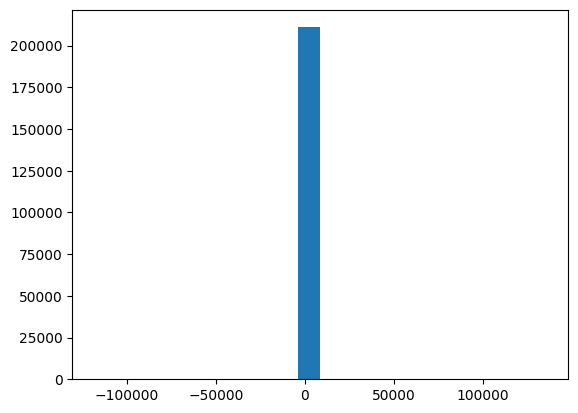

In [81]:
plt.hist(important["Closed PnL"], bins=20)

In [82]:
important["classification"].value_counts()

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

<Axes: xlabel='classification'>

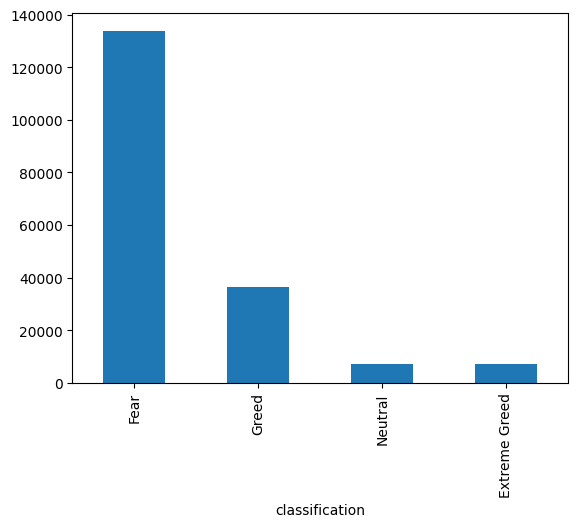

In [83]:
important["classification"].value_counts().plot(kind="bar")

In [84]:
important.groupby("classification")["Closed PnL"].mean()

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64

<Axes: xlabel='classification'>

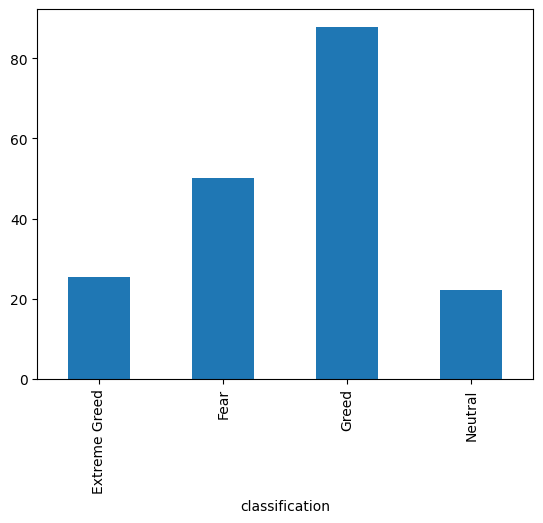

In [85]:
important.groupby("classification")["Closed PnL"].mean().plot(kind="bar")

In [86]:
important.groupby("classification")["Fee"].mean()

classification
Extreme Greed    0.978567
Fear             1.083267
Greed            0.670562
Neutral          1.224461
Name: Fee, dtype: float64

In [87]:
pd.crosstab(
    important["classification"],
    important["Direction"]
)

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,
Extreme Greed,0,88,2389,1931,13,1339,1114,75,0,13,0
Fear,0,7977,36555,20232,36,37828,23472,7687,1,43,40
Greed,0,5806,5105,4129,5,5479,5886,9833,0,7,39
Neutral,8,786,886,1799,0,918,2389,295,0,2,58


In [88]:
pd.crosstab(
    important["classification"],
    important["Side"]
)

Side,BUY,SELL
classification,,
Extreme Greed,3371,3591
Fear,66081,67790
Greed,15421,20868
Neutral,3505,3636


In [89]:
important.groupby("classification")["Size USD"].mean()

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64

In [90]:
important.corr(numeric_only=True)

,Execution Price,Size Tokens,Size USD,Closed PnL,Fee,Start Position,value
Execution Price,1.000000,-0.017185,0.189855,-0.006505,0.225265,0.017241,-0.070793
Size Tokens,-0.017185,1.000000,0.013310,0.005068,0.006710,0.044660,0.035295
Size USD,0.189855,0.013310,1.000000,0.123589,0.745939,0.007787,-0.024110
Closed PnL,-0.006505,0.005068,0.123589,1.000000,0.084020,0.004066,0.011132
Fee,0.225265,0.006710,0.745939,0.084020,1.000000,0.010559,-0.028988
Start Position,0.017241,0.044660,0.007787,0.004066,0.010559,1.000000,0.018870
value,-0.070793,0.035295,-0.024110,0.011132,-0.028988,0.018870,1.000000


<Axes: >

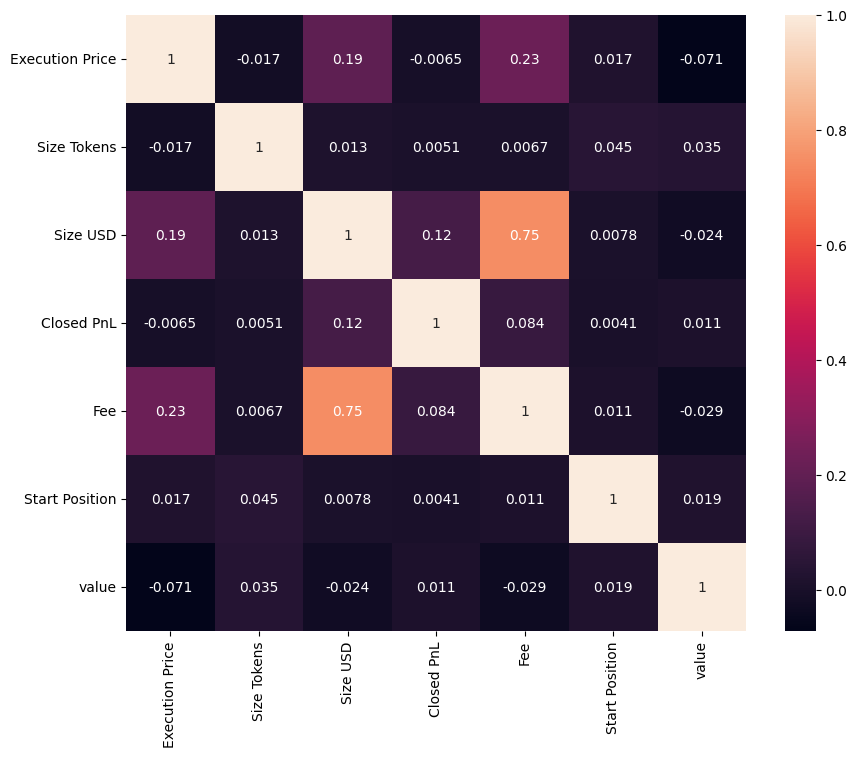

In [91]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(
    important.corr(numeric_only=True),
    annot=True
)

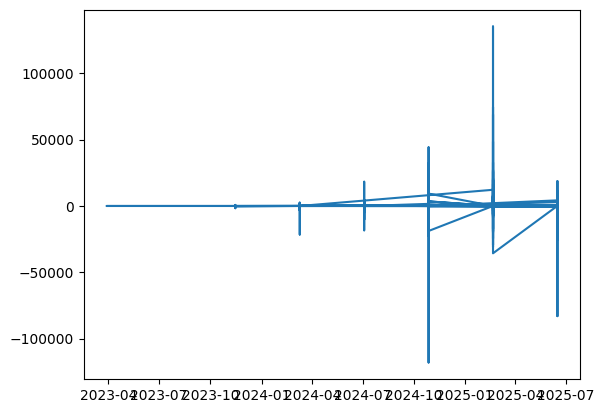

In [92]:
plt.plot(
    important["Timestamp"],
    important["Closed PnL"]
)

<Axes: >

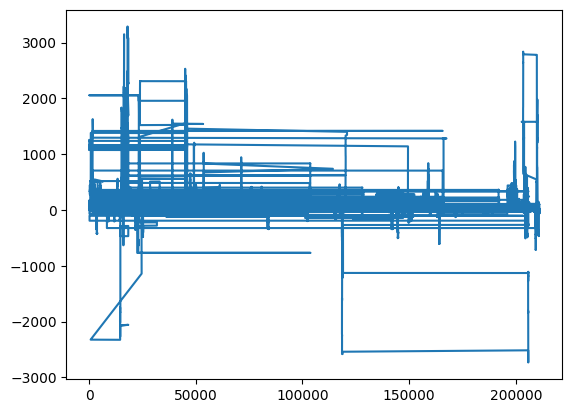

In [93]:
important = important.sort_values("Timestamp")

important["Closed PnL"].rolling(100).mean().plot()

<Axes: xlabel='classification', ylabel='Closed PnL'>

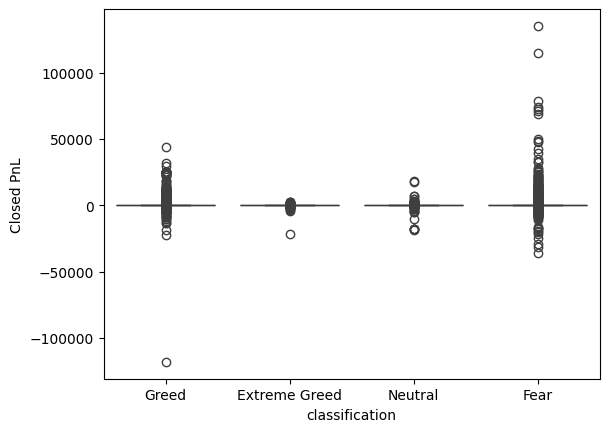

In [94]:
import seaborn as sns

sns.boxplot(
    x="classification",
    y="Closed PnL",
    data=important
)

# EDA

In [95]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,74.0,Greed


In [96]:
merged.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'value', 'classification'],
      dtype='object')

In [97]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  object        
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad